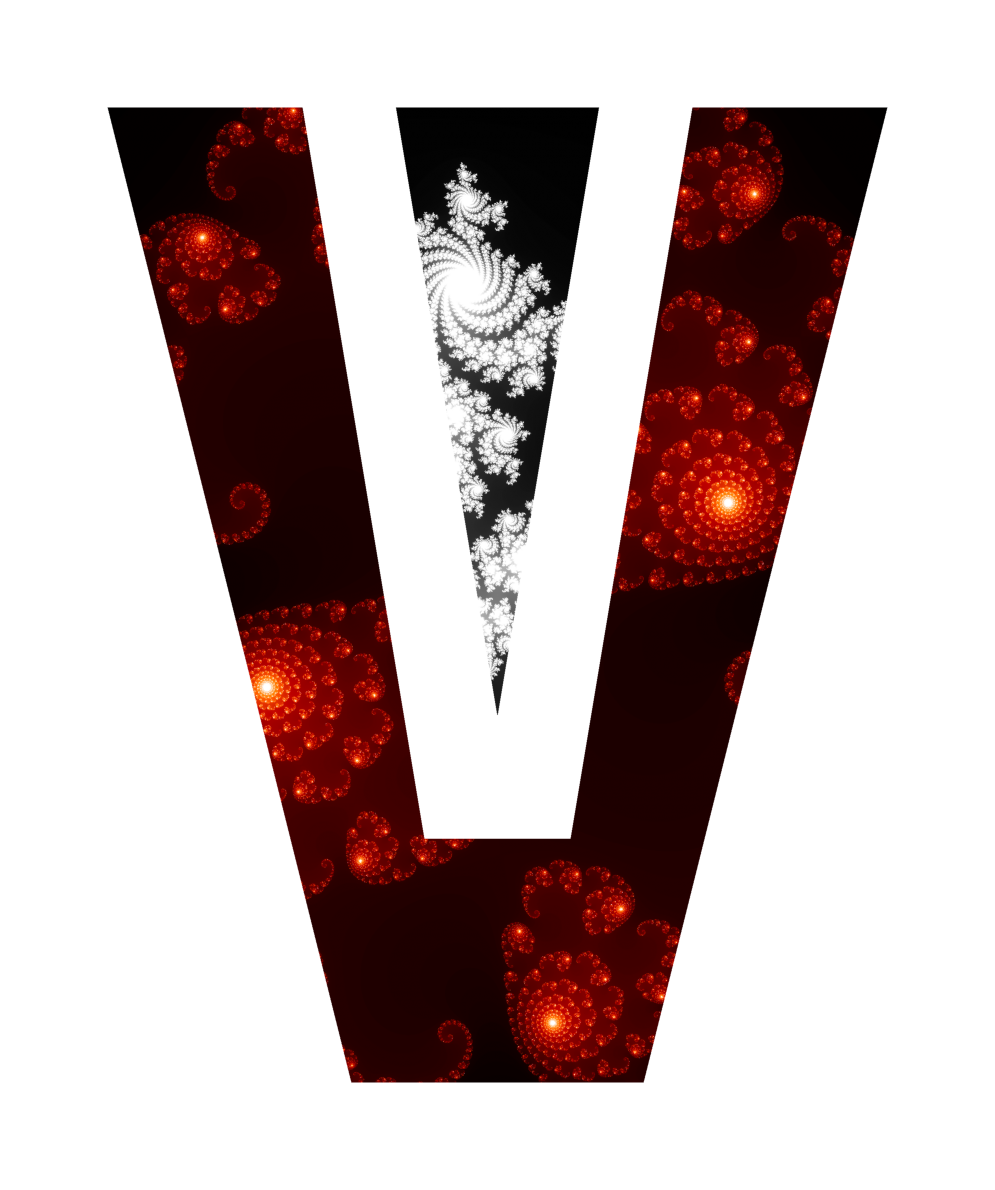

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path


# ============================================================
# PARTE 2 — Julia Sets (área vermelha e triângulo)
# ============================================================
def calcular_julia(xmin, xmax, ymin, ymax, largura, altura, c, max_iter=200):
    """
    Para cada ponto z0 = x + yi do plano, itera z = z^2 + c e guarda em
    quantas iterações o ponto "escapou" (|z| > 2). Pontos que nunca escapam
    pertencem ao conjunto de Julia (ficam com o valor máximo).
    """
    x = np.linspace(xmin, xmax, largura)
    y = np.linspace(ymin, ymax, altura)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    escape = np.zeros(Z.shape, dtype=float)
    ativos = np.ones(Z.shape, dtype=bool)

    for i in range(max_iter):
        Z[ativos] = Z[ativos] ** 2 + c
        escapou_agora = ativos & (np.abs(Z) > 2)
        escape[escapou_agora] = i
        ativos &= ~escapou_agora

    escape[ativos] = max_iter
    return escape, X, Y


def julia_recortado_no_poligono(ax, poligonos, xmin, xmax, ymin, ymax,
                                 c, resolucao=1600, max_iter=200, cmap_nome='hot'):
    """
    Calcula o Julia Set numa grade retangular e exibe SOMENTE os pixels que
    caem dentro de um dos polígonos (união). O resto fica transparente.
    """
    escape, X, Y = calcular_julia(xmin, xmax, ymin, ymax, resolucao, resolucao, c, max_iter)

    pts = np.column_stack([X.ravel(), Y.ravel()])
    dentro = np.zeros(pts.shape[0], dtype=bool)
    for poligono in poligonos:
        dentro |= Path(poligono).contains_points(pts)
    dentro = dentro.reshape(X.shape)

    escape_norm = escape / escape.max()
    cmap = plt.get_cmap(cmap_nome)
    rgba = cmap(escape_norm)
    rgba[..., 3] = dentro.astype(float)  # alpha: 1 dentro do polígono, 0 fora

    ax.imshow(rgba, extent=[xmin, xmax, ymin, ymax], origin='lower', zorder=1)


# ============================================================
# MONTAGEM DO LOGOTIPO
# ============================================================
# facecolor='none' na figura inteira: sem isso, mesmo salvando com
# transparent=True, alguns visualizadores/back-ends ainda mostram um fundo
# branco "residual". Deixar tanto fig quanto ax sem cor de fundo garante que
# só os pixels dos fractais (dentro dos polígonos) tenham alpha > 0.
fig, ax = plt.subplots(figsize=(12, 12), facecolor='none')
ax.set_facecolor('none')

# Braços do "V" e base plana (mesma geometria de sempre)
braco_esq = [(-0.8, 1.0), (-0.4, 1.0), (-0.15, -0.5), (-0.425, -0.5)]
braco_dir = [(0.4, 1.0), (0.8, 1.0), (0.425, -0.5), (0.15, -0.5)]
base_plana = [(-0.425, -0.5), (0.425, -0.5), (0.3, -1.0), (-0.3, -1.0)]

# --- Julia Set preenchendo toda a área vermelha (braços + base) ---
# c = 0.285 + 0.01j é uma constante clássica que gera espirais e filamentos
# bem distribuídos (boa cobertura visual em toda a área, não só nas bordas).
julia_recortado_no_poligono(
    ax,
    poligonos=[braco_esq, braco_dir, base_plana],
    xmin=-1, xmax=1, ymin=-1.2, ymax=1.2,
    c=0.285 + 0.01j,
    resolucao=2400,      # aumente para mais nitidez (custa mais memória/tempo)
    max_iter=200,
    cmap_nome='gist_heat'      # paleta preto -> vermelho -> amarelo -> branco
)

# --- Triângulo preto: também um Julia Set (constante diferente da área vermelha) ---
# c = -0.7 + 0.27015j é a constante "clássica" do Julia Set — bom contraste
# preto/branco e bastante detalhe visível mesmo numa área pequena e estreita.
topo_y = 1.0
apice_y = -0.25  # <- ajuste este valor para subir/descer a ponta do triângulo

# braco_esq: [topo_ext, topo_int, fundo_int, fundo_ext] -> indices 1 e 2 = borda interna
# braco_dir: [topo_int, topo_ext, fundo_ext, fundo_int] -> indices 0 e 3 = borda interna
slope_esq = (braco_esq[2][1] - braco_esq[1][1]) / (braco_esq[2][0] - braco_esq[1][0])
slope_dir = (braco_dir[3][1] - braco_dir[0][1]) / (braco_dir[3][0] - braco_dir[0][0])

topo_esq_x = (topo_y - apice_y) / slope_esq
topo_dir_x = (topo_y - apice_y) / slope_dir

triangulo_preto = [(topo_esq_x, topo_y), (topo_dir_x, topo_y), (0.0, apice_y)]

julia_recortado_no_poligono(
    ax,
    poligonos=[triangulo_preto],
    xmin=-1, xmax=1, ymin=-1.2, ymax=1.2,
    c=-0.7 + 0.27015j,
    resolucao=2400,
    max_iter=200,
    cmap_nome='gray'   # preto -> branco, para manter o contraste do triângulo
)

ax.set_xlim(-1, 1)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()

plt.savefig(
    r"C:\Users\crist\OneDrive\Imagens\fractal.png",
    dpi=600,
    facecolor='none',
    transparent=True
)


plt.show()